# Week 8: Can Our UHPC Models Generalize to Unseen Publications?

## Publication-Held-Out Evaluation of Linear Family Models

**Target:** UHPC 28-day compressive strength (`cs_28d`)  
**Feature policy:** Teammate semantic-recoded 50% policy  
**Models:** OLS, Elastic Net, Bayesian Ridge, Polynomial Ridge

This notebook explains the complete Week 8 strategy, why publication-aware evaluation was necessary, how leakage was prevented, how models were selected, what every metric and plot means, and what the results reveal about the dataset.

## Executive Summary

Week 7 showed that Polynomial Ridge performed strongly when the dataset was split by rows while identical feature vectors were kept together. However, rows from the same research publication could still appear in different splits. This can make evaluation optimistic because rows from one paper often share materials, laboratory practices, curing procedures, testing standards, and reporting conventions.

Week 8 changes the evaluation unit from a **row** to a **publication**. Every row from a publication remains entirely inside train, validation, or test.

### Main result

- Publication-held-out validation selected **Elastic Net**, not Polynomial Ridge.
- Same frozen Elastic Net, row-mixed test RMSE: **21.900 MPa**.
- Same frozen Elastic Net, publication-held-out test RMSE: **34.465 MPa**.
- Generalization gap: **+12.565 MPa RMSE**.
- Publication-held-out test R2: **-0.292**.

**Conclusion:** the row-mixed evaluation was substantially optimistic. The available predictors do not fully capture the differences between publications.

## 1. Research Question and Strategy

### Research question

> Do the Linear Family models learn transferable UHPC material relationships, or do they partly learn publication-specific patterns?

### Why this question matters

A model may perform well when train and test rows come from similar studies, yet fail when applied to a new research group or laboratory. For practical generalization, the stronger question is not *Can the model predict another row?* but *Can it predict an entirely unseen publication?*

### Week 8 workflow

1. Reconstruct and validate publication metadata without using it as a predictor.
2. Create publication-level audits before modeling.
3. Build one shared train/validation/test split with zero publication overlap.
4. Tune models using `GroupKFold` on training publications only.
5. Select the model using validation publications only.
6. Refit the selected model on train plus validation publications.
7. Evaluate once on unseen test publications.
8. Compare the same frozen model under row-mixed and publication-held-out evaluation.
9. Run leave-one-publication-out analysis to measure stability across many publications.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
TABLES = PROJECT_ROOT / 'reports' / 'tables' / 'week08'
METRICS = PROJECT_ROOT / 'results' / 'metrics' / 'week08'
PREDICTIONS = PROJECT_ROOT / 'results' / 'predictions' / 'week08'
FIGURES = PROJECT_ROOT / 'reports' / 'figures' / 'week08'

def load_table(name, folder=TABLES):
    return pd.read_csv(folder / name)

def show_figure(name, width=1100):
    display(Image(filename=str(FIGURES / name), width=width))

publication_summary = load_table('week08_publication_summary.csv')
publication_audit = load_table('week08_publication_audit.csv')
linkage_audit = load_table('week08_metadata_linkage_audit.csv')
split_summary = load_table('week08_publication_split_summary.csv')
split_manifest = load_table('week08_publication_split_manifest.csv')
leakage_audit = load_table('week08_publication_split_leakage_audit.csv')
tuning_summary = load_table('week08_publication_tuning_summary.csv')
tuning_cv = load_table('week08_publication_tuning_cv_results.csv')
validation_metrics = load_table('week08_publication_validation_metrics.csv', METRICS)
selected_model = load_table('week08_selected_publication_model.csv')
final_test_metrics = load_table('week08_unseen_publication_test_metrics.csv', METRICS)
final_test_predictions = load_table('week08_unseen_publication_test_predictions.csv', PREDICTIONS)
split_comparison = load_table('week08_row_mixed_vs_publication_held_out.csv')
lopo_summary = load_table('week08_lopo_micro_macro_summary.csv')
lopo_metrics = load_table('week08_lopo_publication_metrics.csv', METRICS)
lopo_predictions = load_table('week08_lopo_predictions.csv', PREDICTIONS)
worst_publications = load_table('week08_worst_publications.csv')
worst_rows = load_table('week08_worst_rows.csv')

print('Week 8 artifacts loaded successfully.')

Week 8 artifacts loaded successfully.


## 2. Metrics Used and Why

No single metric explains model behavior, so for Week 8, I have reported several complementary metrics.

| Metric | Meaning | Why it is useful |
|---|---|---|
| **MAE** | Average absolute prediction error in MPa | Easy to interpret as the typical error size |
| **RMSE** | Square root of average squared error | Penalizes large errors more strongly; primary selection metric |
| **R2** | Improvement over predicting the evaluation-set mean | Shows explained variance; negative values mean the model is worse than the mean baseline |
| **R** | Correlation between actual and predicted strength | Shows whether predictions follow the correct trend, even if biased |
| **Bias** | Mean of `Actual - Predicted` | Positive means systematic underprediction; negative means overprediction |
| **MedianAE** | Median absolute error | Less sensitive than MAE/RMSE to a few extreme mistakes |
| **MaximumAE** | Largest absolute error | Identifies worst-case prediction risk |

**Why RMSE is the primary selection metric:** large UHPC strength errors are especially undesirable, and RMSE gives them more weight. MAE, Bias, and MedianAE are still required to determine whether the RMSE is caused by broad model weakness, systematic bias, or a few extreme rows.

## 3. Dataset Lineage and Fair Comparison with Week 7

Semantic-recoded 50% representation is treated as a fixed feature policy. The corrected semantic source contains **2,073 valid target rows**. To make Week 8 directly comparable with Week 7, the same 25 exact feature-and-target duplicates are removed, leaving **2,048 modeling rows**.

Publication metadata is recovered from the original workbook and saved in a separate aligned sidecar. Metadata fields include publication ID, source, country, year, mix ID, and stable row IDs.

These metadata columns are used only for splitting, tracking, and interpretation. They are never model predictors.

In [2]:
important_linkage_items = [
    'semantic_source_rows', 'lineage_source_rows', 'exact_duplicate_rows_removed',
    'week08_modeling_rows', 'publication_groups', 'missing_publication_groups',
    'metadata_columns_in_predictors', 'matches_week07_linear_ready_exactly',
    'semantic_row_ids_unique', 'modeling_row_ids_unique'
]
linkage_audit[linkage_audit['item'].isin(important_linkage_items)].reset_index(drop=True)

,item,value
0,semantic_source_rows,2073
1,lineage_source_rows,2073
2,exact_duplicate_rows_removed,25
3,week08_modeling_rows,2048
4,publication_groups,164
5,missing_publication_groups,0
6,metadata_columns_in_predictors,0
7,matches_week07_linear_ready_exactly,True
8,semantic_row_ids_unique,True
9,modeling_row_ids_unique,True


### Lineage interpretation

- The Week 8 modeling table exactly matches the Week 7 linear-ready table, ensuring a fair split-strategy comparison.
- Publication metadata is complete for grouping and absent from predictors.
- The corrected source contains 165 publications, but one publication (`Ref-151-Research`) disappears entirely after Week 7-equivalent exact-duplicate removal. Therefore, the final modeling table contains **164 represented publications**.
- Stable row IDs are preserved so every prediction and worst-case row can be traced back to its source.

## 4. Publication Audit Before Modeling

Before fitting models, publications are audited for group size, target distribution, missingness, dominant curing method, fiber usage, and important ingredient ranges.

This audit answers several questions:

- Are a few publications responsible for a large share of rows?
- Are some publications too small for reliable publication-level conclusions?
- Do publications differ in strength range, curing, fiber usage, or composition?
- Could publication imbalance dominate aggregate metrics?

In [3]:
publication_summary.round(3)

,modeling_rows,publication_groups,minimum_group_rows,median_group_rows,maximum_group_rows,publications_with_at_least_minimum_rows,rows_in_publications_with_at_least_minimum_rows,largest_publication_row_percentage
0,2048,164,1,8.0,110,6,446,5.371


In [4]:
publication_audit[[
    'publication_group', 'publication_country', 'publication_year', 'n_rows',
    'target_mean', 'target_std', 'target_min', 'target_max',
    'dominant_curing_method', 'fiber_used_percentage',
    'missing_cells_per_row_mean'
]].head(12).round(2)

,publication_group,publication_country,publication_year,n_rows,target_mean,target_std,target_min,target_max,dominant_curing_method,fiber_used_percentage,missing_cells_per_row_mean
0,Ref-144-Research,Portugal,2015.0,110,156.63,30.11,90.00,229.00,Heat Curing,34.55,1.31
1,Ref-121-Research,USA,2024.0,78,164.92,29.40,110.00,225.00,Standard Curing,60.26,1.79
2,Ref-48-Research,India,2018.0,72,188.10,28.48,100.00,234.00,Heat Curing,95.83,0.42
3,Ref-141-Research,China,2015.0,71,132.49,12.69,105.40,163.70,Standard Curing,0.00,2.00
4,Ref-85-Research,China,2016.0,64,173.25,30.63,112.00,232.00,Standard Curing,75.00,0.50
5,Ref-139-Research,USA,2019.0,51,134.10,19.95,80.00,169.30,Steam Curing,43.14,2.14
6,Ref-135-Research,USA,2022.0,43,115.47,18.62,83.40,147.20,Heat Curing,51.16,2.44
7,Ref-153-Research,Korea,2019.0,41,158.67,26.39,97.02,206.25,Steam Curing,100.00,1.00
8,Ref-116-Research,China,2021.0,36,152.63,14.51,134.20,182.20,Steam Curing,97.22,0.06
9,Ref-70-Research,China,2021.0,30,167.50,29.83,115.00,220.00,Autoclave Curing,100.00,0.00


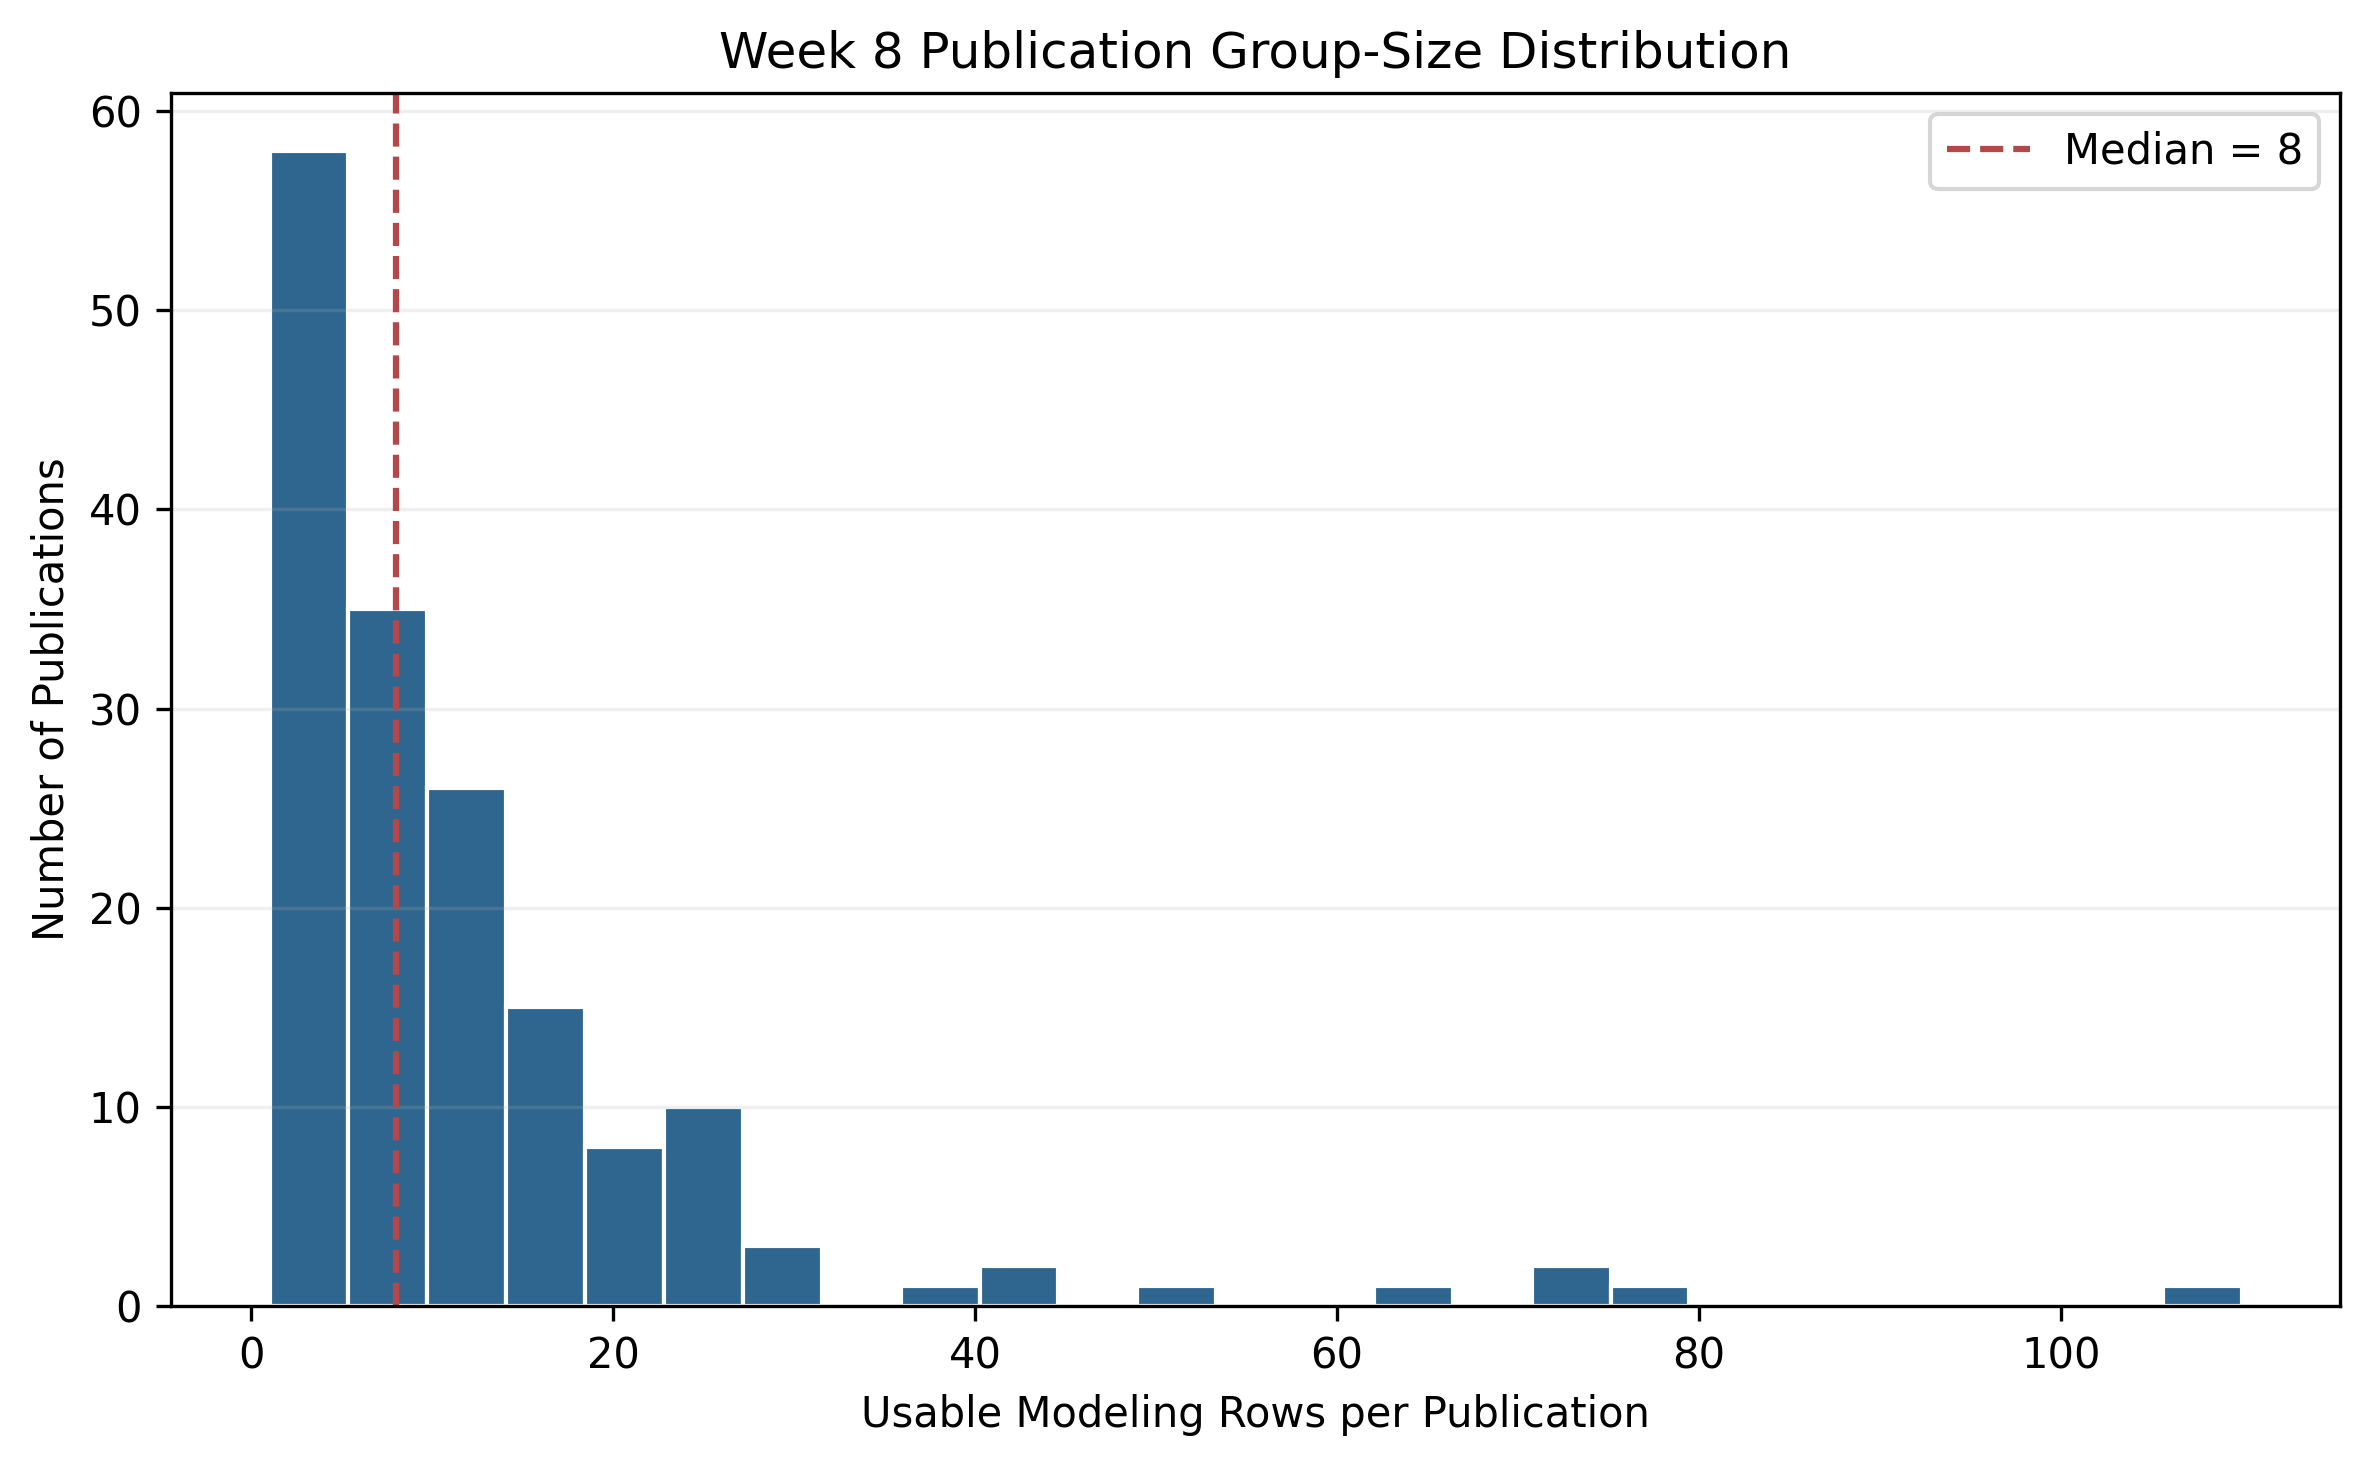

In [5]:
show_figure('week08_publication_group_sizes.png', width=850)

### Publication audit interpretation

- Publication sizes are strongly unequal: the median publication contributes 8 rows, while the largest contributes 110 rows.
- Only 6 publications contain at least 50 usable rows, so the reliability rule focuses LOPO analysis on publications with more stable group-level metrics.
- Publications differ substantially in mean strength, strength range, curing method, and fiber usage.
- Because large publications can dominate row-level metrics, Week 8 reports both **micro** metrics, where every row has equal weight, and **macro** metrics, where every publication has equal weight.

## 5. Leakage Rules

Publication-held-out evaluation is useful only if the split and preprocessing are leakage-safe.

### Rules followed

1. Publication ID, publication source, year, country, mix ID, and row IDs are never predictors.
2. Complete publications stay together in train, validation, or test.
3. Publication assignment uses group sizes only, never target values.
4. Imputation, missing indicators, one-hot encoding, scaling, polynomial expansion, and model fitting remain inside sklearn pipelines.
5. Hyperparameter tuning uses publication groups from training data only.
6. Validation publications select the model; test publications remain untouched until the final evaluation.
7. Leave-one-publication-out fits a fresh pipeline after removing the held publication.

In [6]:
leakage_audit

,check,value,status
0,train_validation_publication_overlap,0,pass
1,train_test_publication_overlap,0,pass
2,validation_test_publication_overlap,0,pass
3,manifest_assignment_uses_target_values,False,pass
4,all_modeling_rows_assigned,2048,pass


Every leakage audit check passes. There is zero publication overlap between train, validation, and test, all 2,048 modeling rows are assigned, and the split manifest confirms target values were not used during assignment.

## 6. Shared Publication-Held-Out Split

Every model uses the same split manifest. The split algorithm balances both the number of rows and the number of publications while using publication sizes only.

Target proportions:

- 70% training rows
- 15% validation rows
- 15% test rows

A shared split is important because model differences should come from model behavior, not from receiving easier or harder publications.

In [7]:
split_summary.round(3)

,split,n_rows,row_percentage,n_publications,target_mean,target_std,target_min,target_max,missing_predictor_cells,missing_predictor_cells_per_row
0,train,1434,70.02,115,149.484,35.836,80.0,298.0,1680,1.172
1,validation,307,14.99,25,155.491,42.951,80.0,281.0,473,1.541
2,test,307,14.99,24,148.053,30.370,83.0,243.0,415,1.352


In [8]:
split_manifest.groupby('split').agg(
    publications=('publication_group', 'nunique'),
    rows=('n_rows', 'sum'),
    smallest_publication=('n_rows', 'min'),
    median_publication=('n_rows', 'median'),
    largest_publication=('n_rows', 'max'),
).round(2)

,publications,rows,smallest_publication,median_publication,largest_publication
split,,,,,
test,24,307,2,4.0,110
train,115,1434,1,10.0,72
validation,25,307,1,5.0,78


### Split interpretation

The split reaches almost exact row proportions: 1,434 train rows and 307 rows in both validation and test. It contains 115 training publications, 25 validation publications, and 24 test publications.

Target means and target ranges differ across splits, even though targets were not used during assignment. This is expected when complete publications are held together: publications often cover specific strength ranges. That natural distribution shift is part of the generalization challenge, not something to remove by looking at test targets.

## 7. Models and Preprocessing

For Week 8 also I have used the same four Linear Family models as in the corrected Week 7 workflow:

### OLS
A simple unregularized reference. It shows how well a standard linear relationship works without coefficient shrinkage.

### Elastic Net
Combines L1 and L2 regularization. It can shrink unstable coefficients and reduce the influence of correlated or weak features.

### Bayesian Ridge
Uses probabilistic regularization. It provides another stable linear alternative when predictors are correlated or noisy.

### Polynomial Ridge
Adds second-degree terms and interactions after preprocessing, then applies Ridge regularization. It can represent nonlinear relationships but has greater risk of learning publication-specific interactions.

### Train-fitted preprocessing inside every pipeline

- Numeric median imputation with missing indicators
- Numeric standard scaling
- Categorical missing-value imputation
- Rare-aware unknown-safe one-hot encoding
- Polynomial expansion only inside Polynomial Ridge

Keeping preprocessing inside each pipeline ensures every cross-validation fold learns preprocessing from its own training publications only.

## 8. Publication-Group Hyperparameter Tuning

Hyperparameter tuning uses three-fold `GroupKFold` on the 115 training publications. Publications, not rows, define the folds.

The primary tuning score is cross-validation RMSE. OLS has no meaningful regularization hyperparameters and remains an untuned reference.

After tuning, all four candidates are evaluated on the same unseen validation publications. The final test set is still not used.

In [9]:
tuning_summary[[
    'model', 'tuned', 'cv_strategy', 'grouping', 'candidate_count',
    'best_cv_RMSE', 'best_parameters'
]].round(3)

,model,tuned,cv_strategy,grouping,candidate_count,best_cv_RMSE,best_parameters
0,OLS,False,GroupKFold(n_splits=3),publication_group,1,NaN,{}
1,Elastic Net,True,GroupKFold(n_splits=3),publication_group,25,29.491,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.7}"
2,Bayesian Ridge,True,GroupKFold(n_splits=3),publication_group,9,29.898,"{""model__alpha_1"": 1e-07, ""model__lambda_1"": 1e-05}"
3,Polynomial Ridge,True,GroupKFold(n_splits=3),publication_group,5,32.577,"{""model__alpha"": 1000.0, ""poly__degree"": 2}"


In [10]:
best_cv_candidates = (
    tuning_cv.sort_values(['model', 'rank_cv_RMSE'])
    .groupby('model', as_index=False)
    .head(3)
)
best_cv_candidates[[
    'model', 'rank_cv_RMSE', 'mean_train_cv_RMSE', 'mean_cv_RMSE',
    'std_cv_RMSE', 'candidate_parameters'
]].round(3)

,model,rank_cv_RMSE,mean_train_cv_RMSE,mean_cv_RMSE,std_cv_RMSE,candidate_parameters
25,Bayesian Ridge,1,16.096,29.898,1.533,"{""model__alpha_1"": 1e-07, ""model__lambda_1"": 1e-05}"
26,Bayesian Ridge,2,16.096,29.898,1.533,"{""model__alpha_1"": 1e-06, ""model__lambda_1"": 1e-05}"
27,Bayesian Ridge,3,16.096,29.898,1.533,"{""model__alpha_1"": 1e-05, ""model__lambda_1"": 1e-05}"
0,Elastic Net,1,16.451,29.491,1.192,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.7}"
1,Elastic Net,2,16.747,29.492,1.317,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.5}"
2,Elastic Net,3,17.003,29.515,1.481,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.3}"
34,Polynomial Ridge,1,10.081,32.577,3.281,"{""model__alpha"": 1000.0, ""poly__degree"": 2}"
35,Polynomial Ridge,2,7.188,39.285,5.043,"{""model__alpha"": 100.0, ""poly__degree"": 2}"
36,Polynomial Ridge,3,6.105,57.778,13.978,"{""model__alpha"": 10.0, ""poly__degree"": 2}"


### Tuning interpretation

- Elastic Net has the best group-CV RMSE at about 29.49 MPa.
- Bayesian Ridge is close, suggesting that regularized linear effects are relatively stable.
- Polynomial Ridge has a much lower training error but worse publication-group CV performance. Its selected alpha increases to 1000, showing that strong regularization is needed to control the expanded feature space.
- The difference between train-CV and validation-CV error is evidence that publication generalization is harder than fitting relationships within known publication styles.

## 9. Validation-Publication Model Selection

The model is selected using validation RMSE only. This keeps the final test publications independent from model choice.

The table below shows both training and validation results. The train-to-validation gap is especially important: a large gap suggests the model has learned relationships that do not transfer to unseen publications.

In [11]:
validation_pivot = validation_metrics.pivot_table(
    index='model', columns='split', values=['MAE', 'RMSE', 'R2', 'Bias']
)
validation_pivot.round(3)

Bias                MAE                R2             \
split            train validation   train validation  train validation   
model                                                                    
Bayesian Ridge     0.0     -9.772  12.886     26.136  0.776      0.400   
Elastic Net        0.0     -9.679  13.380     25.532  0.762      0.418   
OLS                0.0     -9.760  12.762     27.040  0.780      0.371   
Polynomial Ridge   0.0     -2.894   7.273     25.180  0.920     -0.038   

                    RMSE             
split              train validation  
model                                
Bayesian Ridge    16.940     33.218  
Elastic Net       17.493     32.725  
OLS               16.810     34.019  
Polynomial Ridge  10.137     43.693

In [12]:
model_selection_view = validation_metrics.query("split == 'validation'").copy()
model_selection_view['RMSE_rank'] = model_selection_view['RMSE'].rank(method='min').astype(int)
model_selection_view[['RMSE_rank', 'model', 'MAE', 'RMSE', 'R2', 'R', 'Bias', 'MedianAE']].sort_values('RMSE').round(3)

,RMSE_rank,model,MAE,RMSE,R2,R,Bias,MedianAE
3,1,Elastic Net,25.532,32.725,0.418,0.726,-9.679,20.512
5,2,Bayesian Ridge,26.136,33.218,0.400,0.728,-9.772,20.942
1,3,OLS,27.040,34.019,0.371,0.726,-9.760,21.289
7,4,Polynomial Ridge,25.180,43.693,-0.038,0.605,-2.894,15.703


### Why Elastic Net was selected

Elastic Net has the lowest validation-publication RMSE at **32.725 MPa**. It also has the best validation R2 among the four candidates.

Polynomial Ridge was the strongest Week 7 row-mixed model, but here its validation RMSE increases to **43.693 MPa** and validation R2 becomes slightly negative. This reversal is a major Week 8 finding: the nonlinear interaction model appears to capture publication-specific structure that does not transfer reliably.

Elastic Net's regularization provides a more conservative and transferable model, even though its absolute publication-held-out performance remains limited.

## 10. Final Evaluation on Unseen Test Publications

After selecting Elastic Net, its hyperparameters and feature configuration are frozen. The model is refitted on train plus validation publications, then evaluated once on the 24 untouched test publications.

This is the final estimate of performance on completely unseen publications.

In [13]:
selected_model.round(3)

,selection_rule,selected_model,validation_RMSE,validation_MAE,validation_R2,final_test_RMSE,final_test_MAE,final_test_R2
0,lowest_publication_validation_RMSE,Elastic Net,32.725,25.532,0.418,34.465,28.226,-0.292


In [14]:
final_test_metrics.round(3)

,policy,experiment,exploratory,model,split,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,training_rows,training_publications
0,semantic_recoding_50_percent,final_unseen_publication_test,False,Elastic Net,test,307,28.226,34.465,-0.292,0.283,-7.129,25.856,1741,140


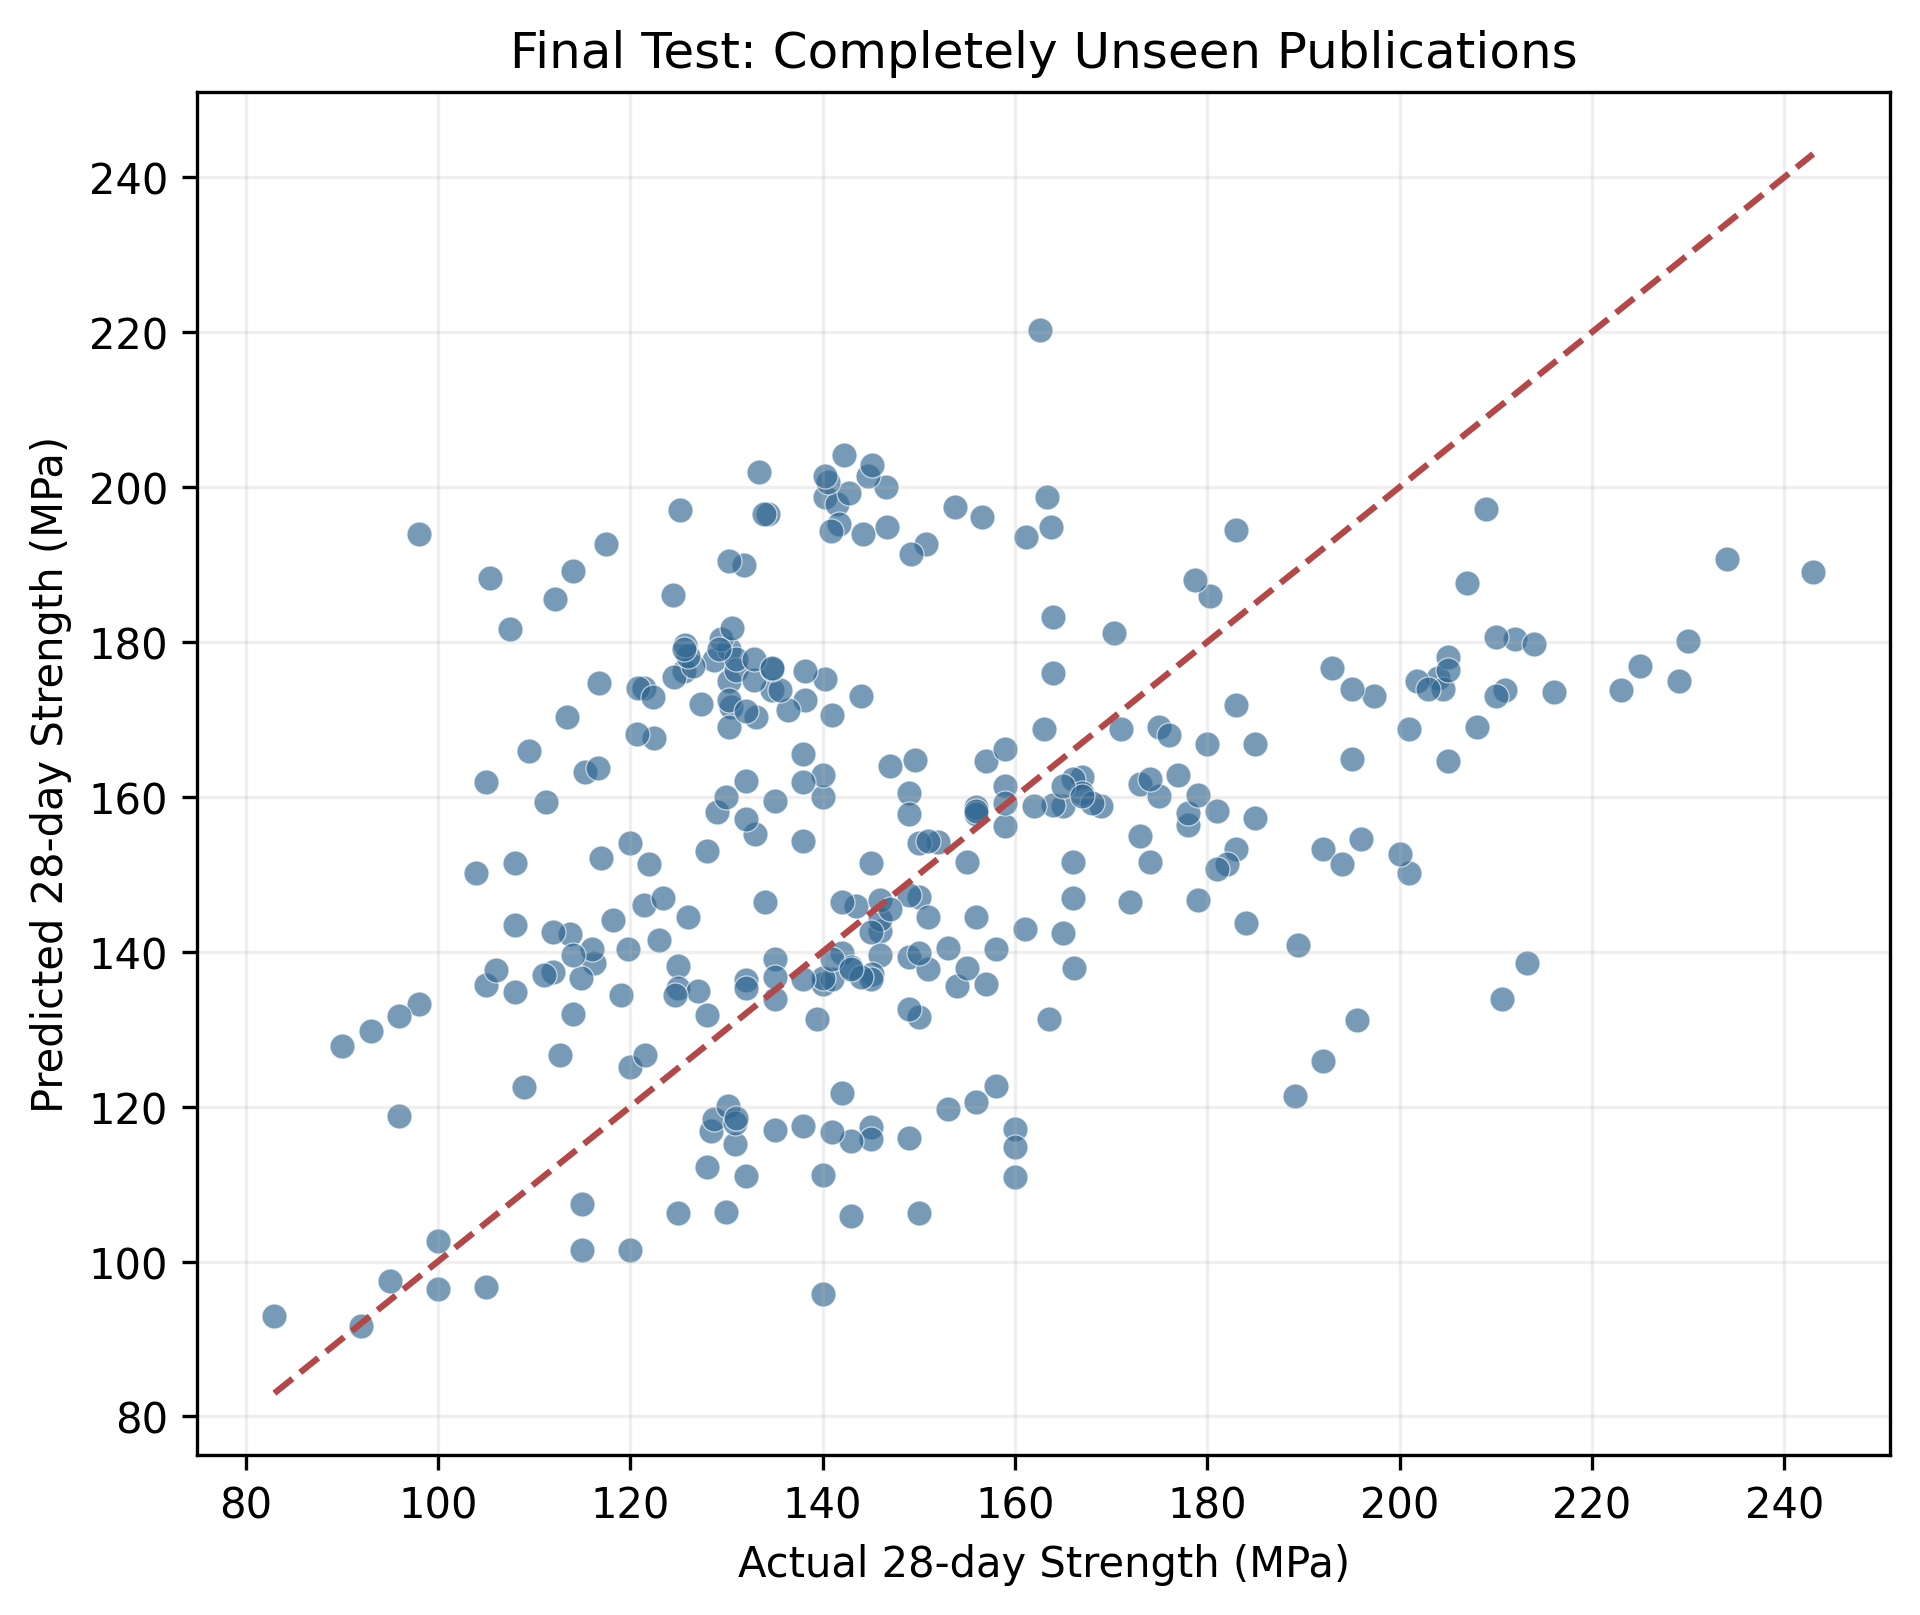

In [15]:
show_figure('week08_unseen_publication_predicted_vs_actual.png', width=800)

### Final-test interpretation

- Test MAE is **28.226 MPa**, so the typical absolute prediction error is large.
- Test RMSE is **34.465 MPa**, meaning several large errors increase the squared-error penalty.
- Test R2 is **-0.292**. On these unseen publications, the model is worse than predicting the test-set mean strength.
- Bias is **-7.129 MPa**, meaning the model systematically overpredicts the unseen test publications on average.
- Correlation remains positive but weak. The model retains some ranking ability, yet its calibration and absolute accuracy do not transfer well.

The predicted-versus-actual plot shows predictions compressed toward the middle. High and low publication-specific strength patterns are not captured sufficiently.

In [16]:
test_publication_errors = (
    final_test_predictions.groupby('publication_group')
    .agg(
        n_rows=('Actual', 'size'),
        actual_mean=('Actual', 'mean'),
        predicted_mean=('Predicted', 'mean'),
        MAE=('AbsoluteError', 'mean'),
        RMSE=('SquaredError', lambda values: np.sqrt(values.mean())),
        Bias=('Residual', 'mean'),
    )
    .sort_values('RMSE', ascending=False)
)
test_publication_errors.head(12).round(3)

,n_rows,actual_mean,predicted_mean,MAE,RMSE,Bias
publication_group,,,,,,
Ref-152-Research,2,211.900,136.247,75.653,75.660,75.653
Ref-167-Research,3,191.367,131.133,60.233,60.806,60.233
Ref-111-Research,2,196.500,138.071,58.429,58.927,58.429
Ref-154-Research,4,96.250,137.272,41.022,52.607,-41.022
Ref-141-Research,71,132.494,183.179,50.685,51.809,-50.685
Ref-158-Research,4,125.250,162.022,36.772,44.320,-36.772
Ref-108-Research,3,121.667,159.598,37.932,40.230,-37.932
Ref-16-Research,11,151.364,116.494,34.869,36.996,34.869
Ref-32-Research,4,150.200,167.039,20.802,30.104,-16.839


The publication-level table shows that final-test error is not evenly distributed. Some publications are predicted reasonably, while others have large systematic overprediction or underprediction. This motivates the broader leave-one-publication-out experiment.

## 11. Fair Comparison: Row-Mixed vs Publication-Held-Out

To isolate the effect of split strategy, the same frozen Elastic Net configuration is evaluated under two settings:

1. **Row-mixed feature-hash split:** identical feature vectors stay together, but publications may cross splits.
2. **Publication-held-out split:** complete publications remain separate.

The intended experimental difference is the split strategy. This is the central Week 8 comparison.

In [17]:
split_comparison[[
    'split_strategy', 'model', 'n_rows', 'MAE', 'RMSE', 'R2', 'R',
    'Bias', 'MedianAE', 'RMSE_gap_vs_row_mixed', 'MAE_gap_vs_row_mixed',
    'R2_gap_vs_row_mixed'
]].round(3)

,split_strategy,model,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,RMSE_gap_vs_row_mixed,MAE_gap_vs_row_mixed,R2_gap_vs_row_mixed
0,row_mixed_feature_hash,Elastic Net,305,16.761,21.900,0.630,0.795,-1.372,13.581,0.000,0.000,0.000
1,publication_held_out,Elastic Net,307,28.226,34.465,-0.292,0.283,-7.129,25.856,12.565,11.465,-0.922


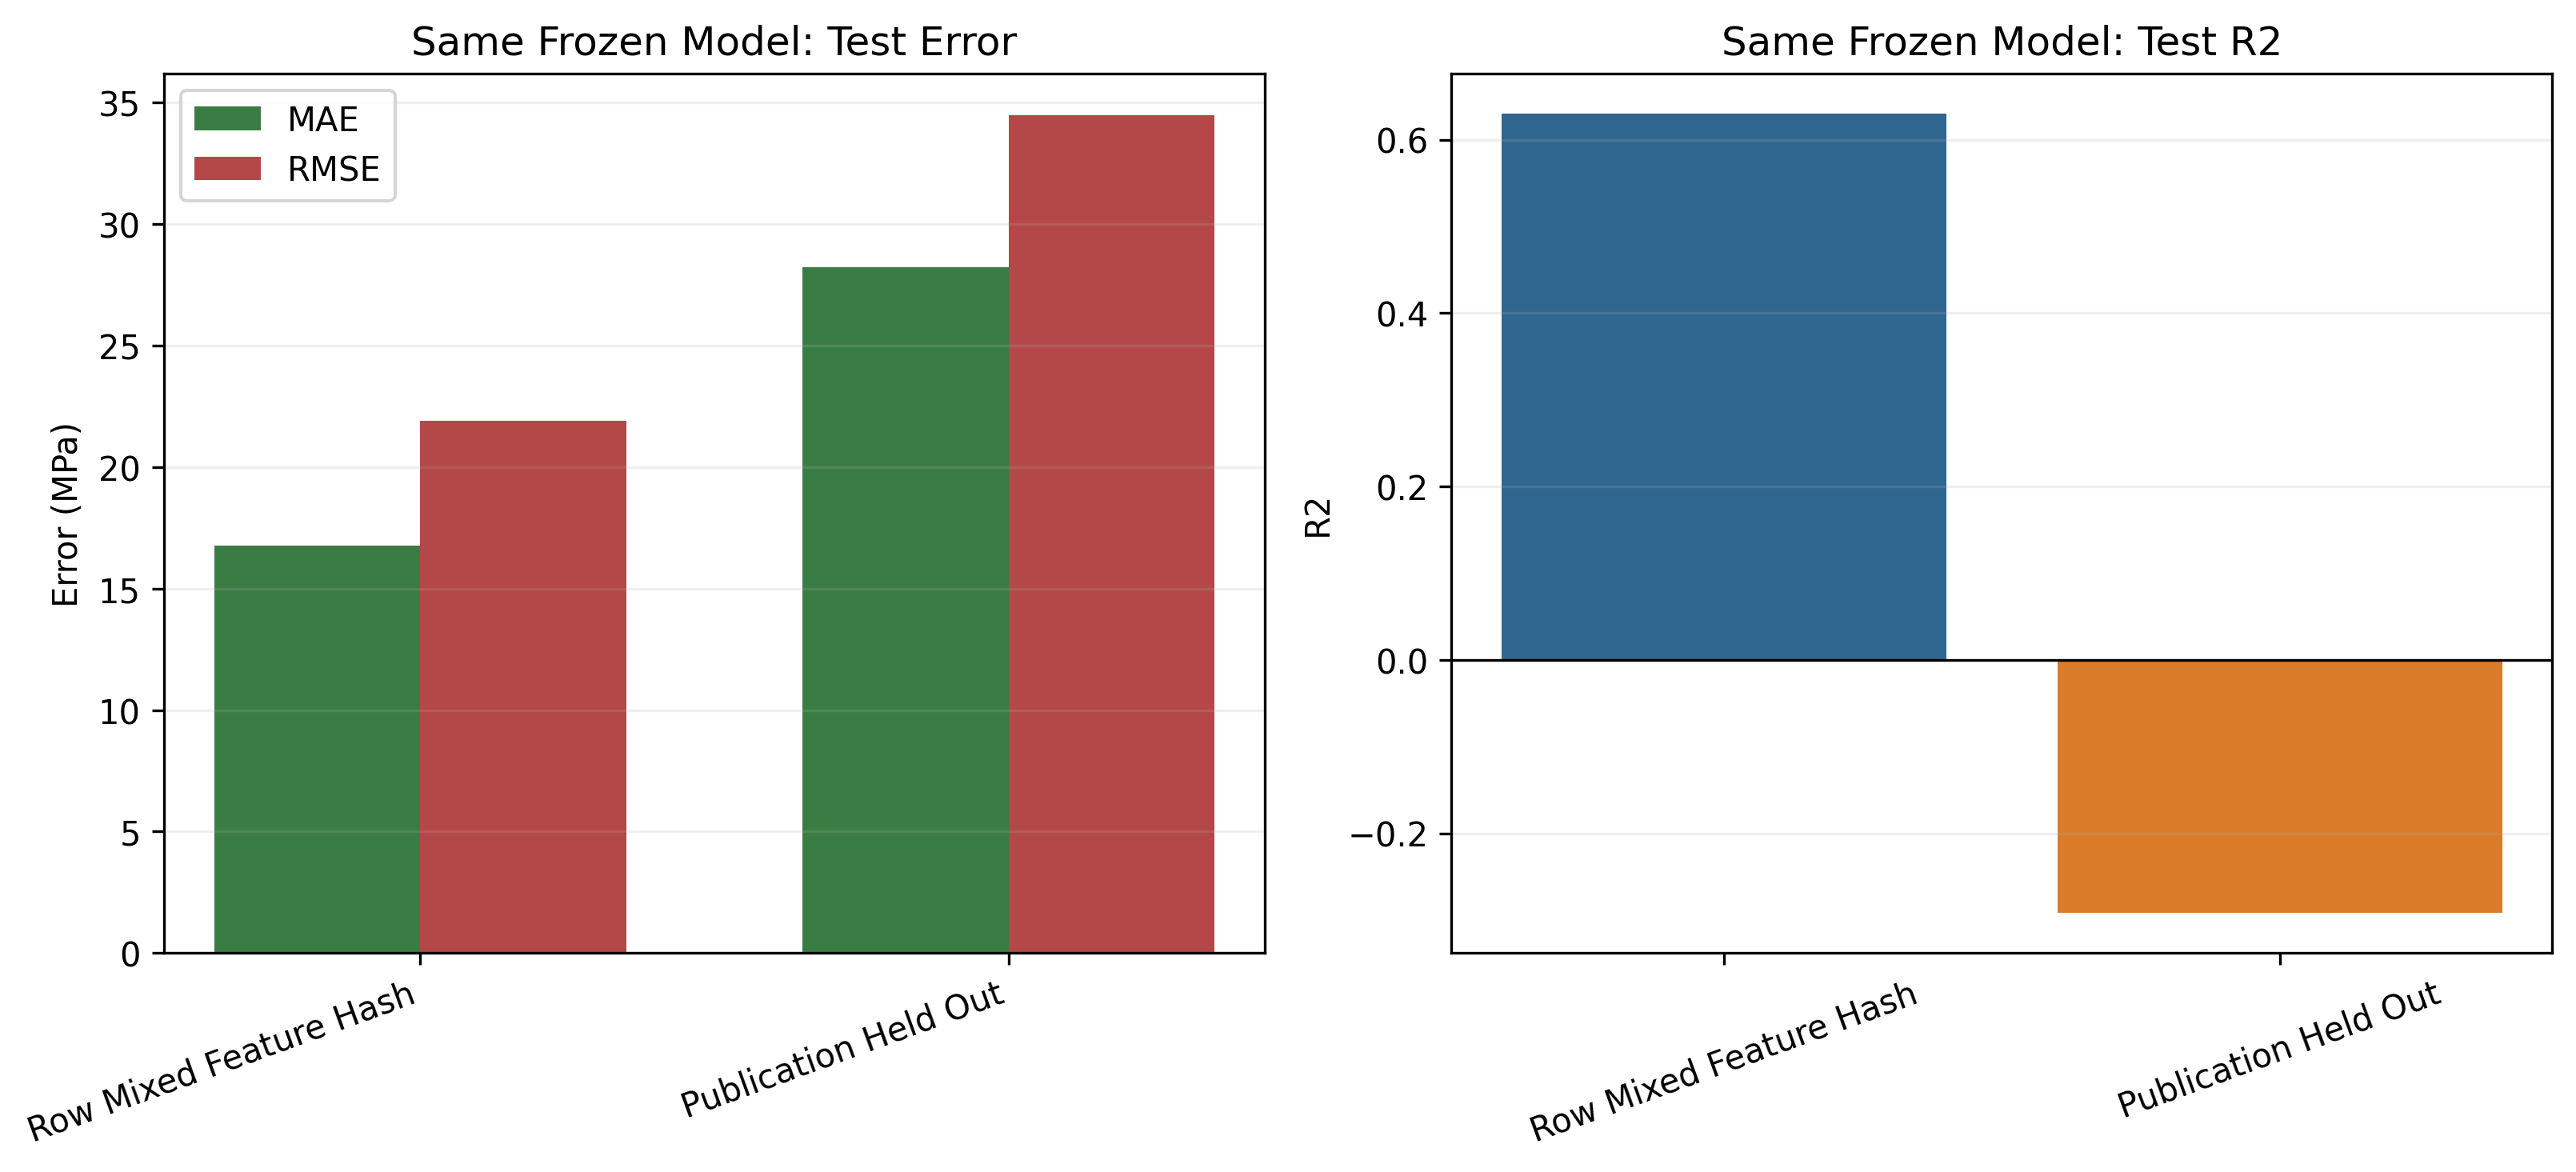

In [18]:
show_figure('week08_row_mixed_vs_publication_held_out.png', width=1200)

### Split-comparison interpretation

- RMSE rises from **21.900** to **34.465 MPa**, a **57% increase**.
- MAE rises by **11.465 MPa**.
- R2 falls from **0.630** to **-0.292**.
- Publication-held-out Bias is more negative, indicating stronger systematic overprediction.

The model performs much better when test rows resemble publication styles already represented in training. This does not mean the row-mixed result is incorrect; it answers an easier question. Week 8 answers the stricter and more practical question of generalization to new publications.

## 12. Leave-One-Publication-Out Evaluation

A single publication-held-out split can be influenced by which publications happen to enter the test set. Leave-one-publication-out provides a broader stability analysis.

For every publication with at least 50 usable rows:

1. Hold out the entire publication.
2. Fit a fresh preprocessing-and-Elastic-Net pipeline on all other publications.
3. Predict the held publication.
4. Calculate publication-level metrics and save row-level predictions.

The selected Elastic Net configuration is frozen; hyperparameter search is not repeated for each publication.

In [19]:
lopo_summary.round(3)

,aggregation,n_publications,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,MaximumAE
0,micro_all_held_out_rows,6,446,29.389,35.009,-0.158,0.306,-6.630,28.081,89.066
1,macro_equal_publication_weight,6,446,30.333,34.942,-2.657,NaN,-7.536,28.971,70.316


### Micro versus macro interpretation

- **Micro metrics** combine all 446 held-out rows from the 6 eligible publications. Large publications contribute more weight. Micro MAE is **29.389 MPa**, RMSE is **35.009 MPa**, and R2 is **-0.158**.
- **Macro metrics** average the 6 publication metrics equally. Macro MAE is **30.333 MPa**, RMSE is **34.942 MPa**, and R2 is **-2.657**.
- The 50-row rule covers **21.8%** of all modeling rows. This is a deliberate tradeoff: each publication metric is based on more observations, but the conclusion applies only to the six largest eligible publications.

Publication-level R2 can become very negative when one publication has a narrow target range. Even moderate errors can be much worse than predicting that publication's own mean. Therefore, publication MAE, RMSE, and Bias are usually more stable for interpreting individual publication failures.

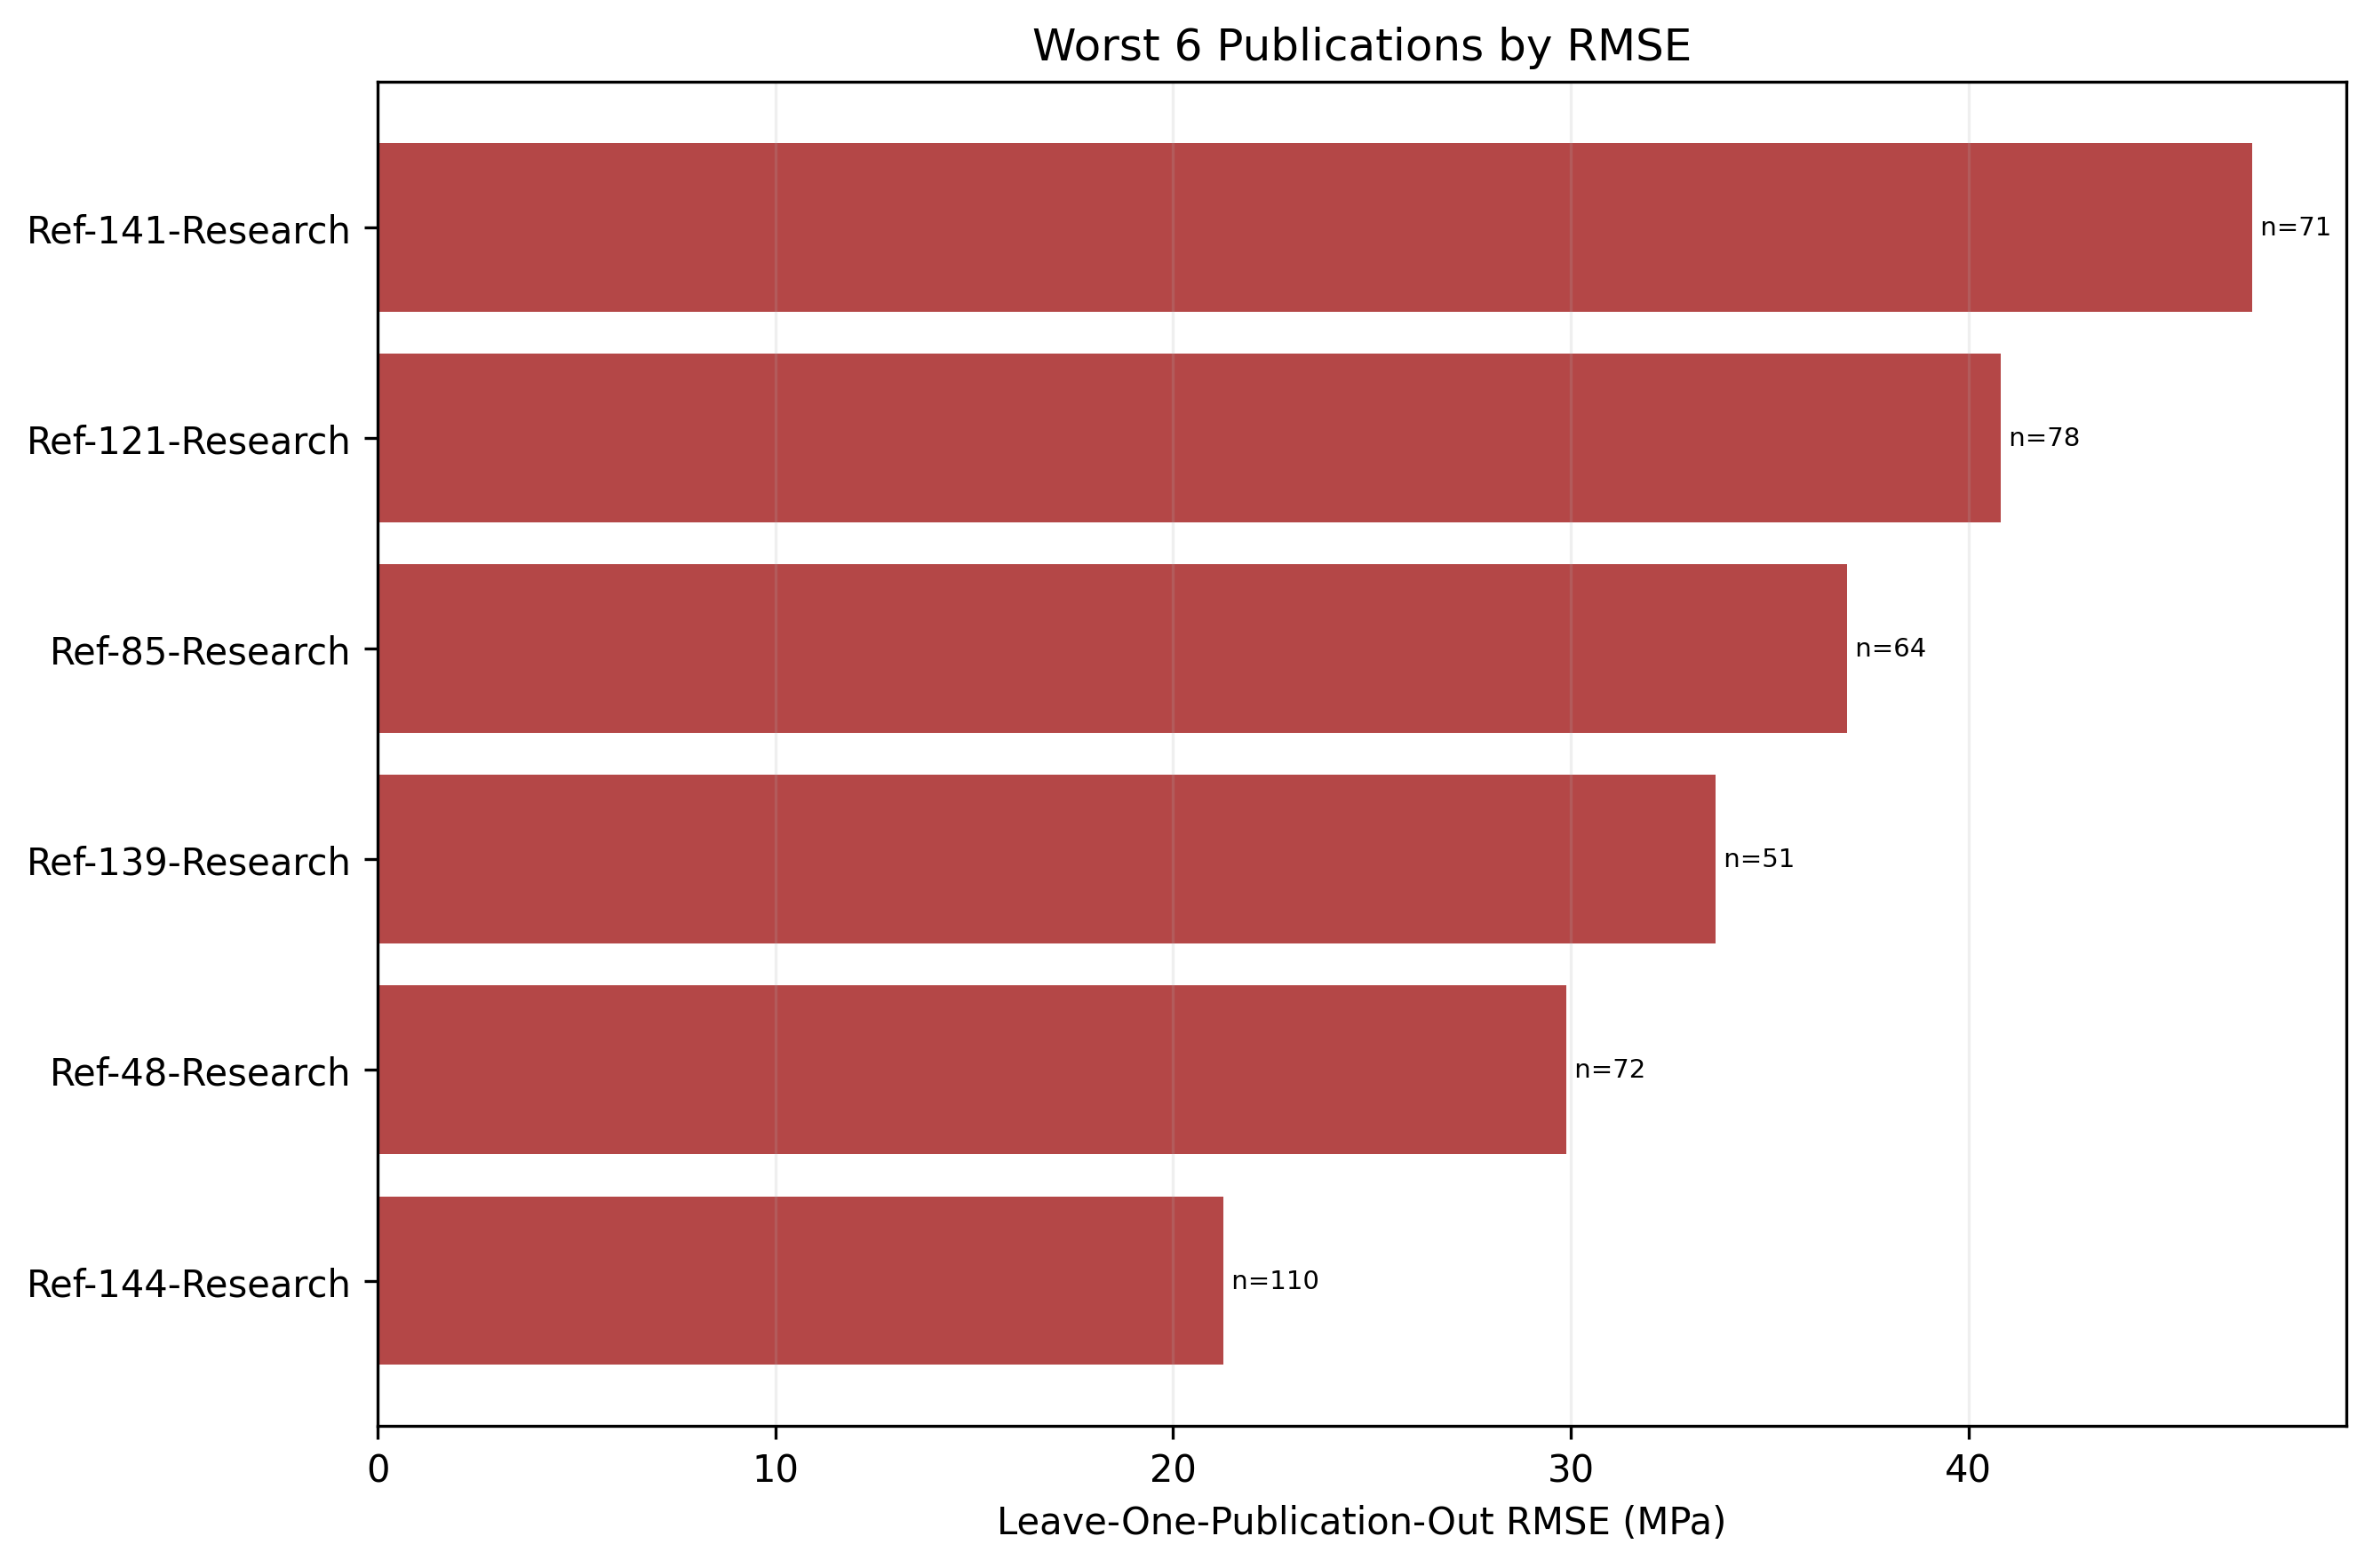

In [20]:
show_figure('week08_lopo_rmse_ranking.png', width=1000)

The LOPO ranking demonstrates that failure persists even after excluding every publication with fewer than 50 rows. `Ref-141-Research` has 71 rows and RMSE **47.139 MPa**; `Ref-121-Research` has 78 rows and RMSE **40.805 MPa**. Therefore, poor transfer cannot be dismissed as metric noise caused only by small publications.

## 13. Systematic Publication Bias

Bias is defined as `Actual - Predicted`:

- Positive Bias: the model underpredicts the publication.
- Negative Bias: the model overpredicts the publication.

Large absolute Bias indicates that the model is consistently shifted for an entire publication, rather than making only a few random mistakes.

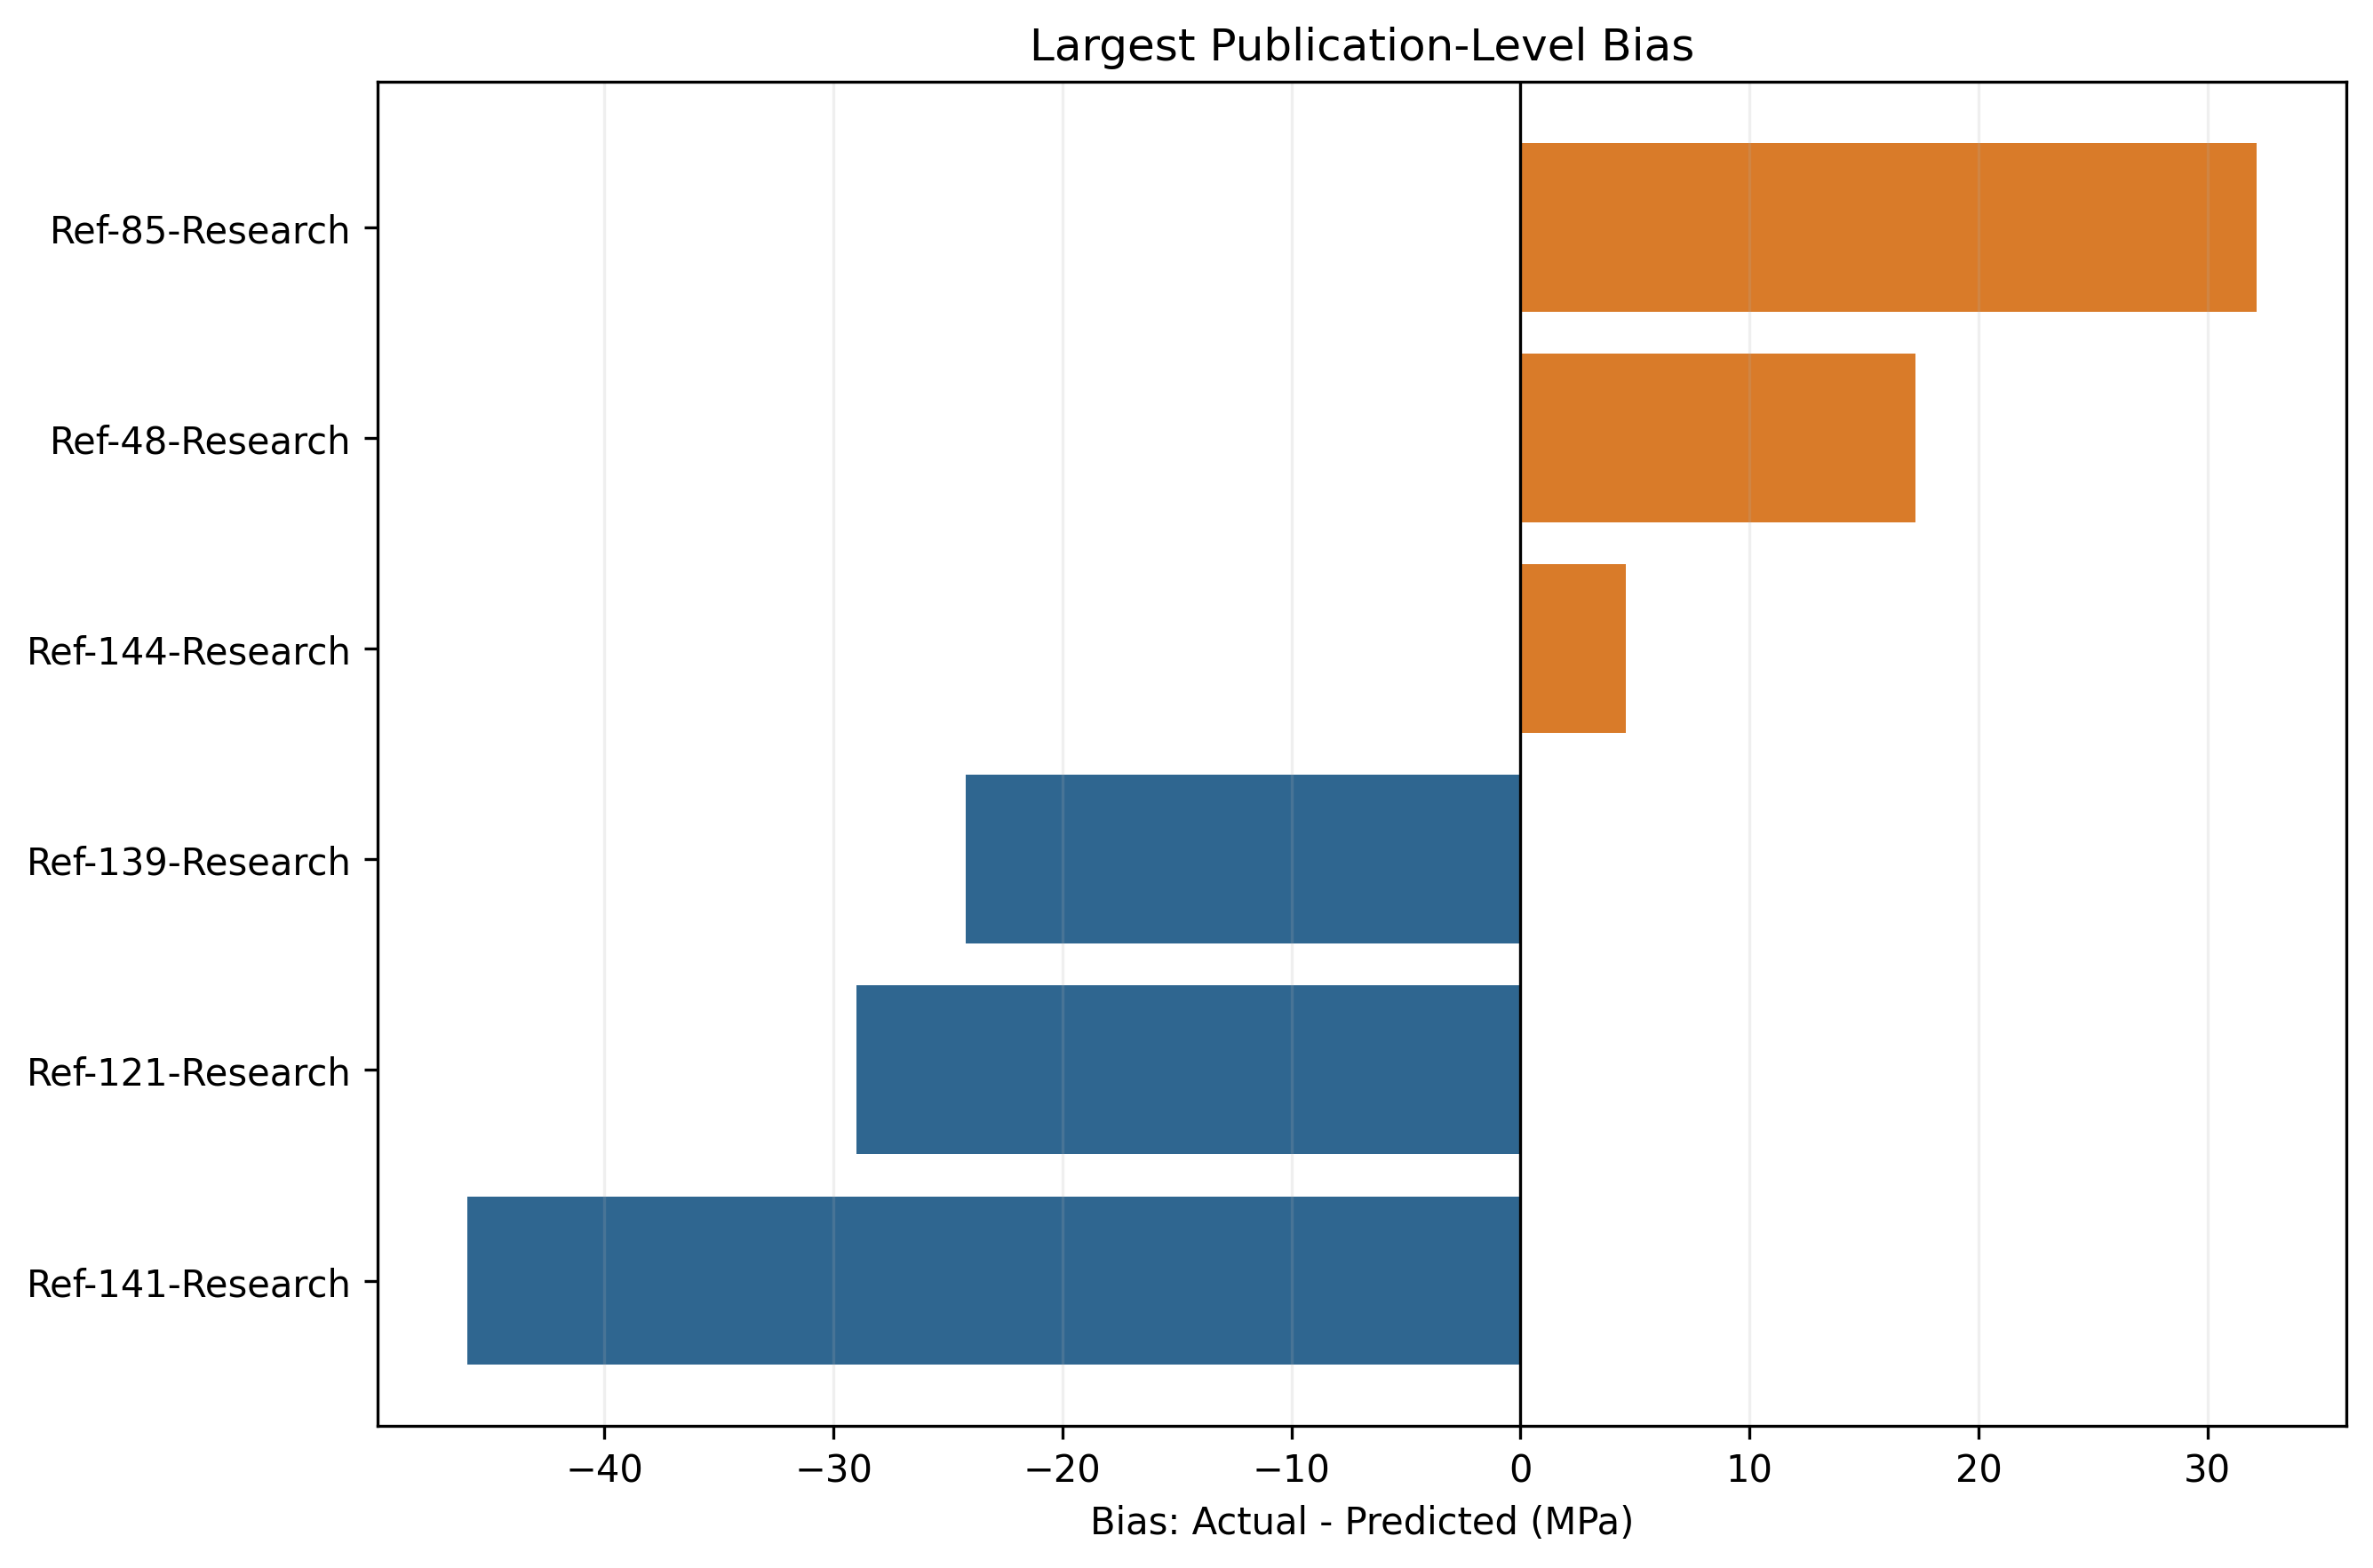

In [21]:
show_figure('week08_lopo_bias.png', width=1000)

In [22]:
worst_publications[[
    'publication_group', 'publication_country', 'publication_year', 'n_rows',
    'MAE', 'RMSE', 'R2', 'Bias', 'MaximumAE',
    'dominant_residual_direction', 'worst_row_squared_error_share'
]].head(15).round(3)

,publication_group,publication_country,publication_year,n_rows,MAE,RMSE,R2,Bias,MaximumAE,dominant_residual_direction,worst_row_squared_error_share
0,Ref-141-Research,China,2015.0,71,45.996,47.139,-12.995,-45.996,77.461,overprediction,0.038
1,Ref-121-Research,USA,2024.0,78,34.202,40.805,-0.951,-28.997,89.066,overprediction,0.061
2,Ref-85-Research,China,2016.0,64,32.503,36.938,-0.477,32.155,67.267,underprediction,0.052
3,Ref-139-Research,USA,2019.0,51,26.194,33.627,-1.898,-24.218,79.232,overprediction,0.109
4,Ref-48-Research,India,2018.0,72,25.871,29.879,-0.116,17.229,55.564,underprediction,0.048
5,Ref-144-Research,Portugal,2015.0,110,17.230,21.263,0.497,4.611,53.309,underprediction,0.057


### Bias interpretation

Many worst publications have Bias nearly as large as MAE. This means most rows within those publications are wrong in the same direction.

Examples:

- `Ref-141-Research` is strongly overpredicted, with Bias **-45.996 MPa** across 71 rows.
- `Ref-121-Research` is also overpredicted, with Bias **-28.997 MPa** across 78 rows.
- `Ref-85-Research` is systematically underpredicted, with Bias **+32.155 MPa** across 64 rows.

This pattern strongly suggests omitted publication-level factors such as laboratory method, material chemistry, specimen/testing procedure, or unrecorded curing details.

## 14. Worst Individual Rows

Worst-row analysis identifies extreme failures and checks whether publication-level RMSE is caused by one row or by broad publication-wide error.

In [23]:
worst_rows[[
    'publication_group', 'semantic_row_id', 'mix_id', 'publication_country',
    'Actual', 'Predicted', 'Residual', 'AbsoluteError'
]].head(20).round(3)

,publication_group,semantic_row_id,mix_id,publication_country,Actual,Predicted,Residual,AbsoluteError
0,Ref-121-Research,1357,UHPGC16,USA,110.0,199.066,-89.066,89.066
1,Ref-121-Research,1348,UHPGC7,USA,132.0,218.039,-86.039,86.039
2,Ref-121-Research,1354,UHPGC13,USA,123.0,203.020,-80.020,80.020
3,Ref-139-Research,1629,UHPC-39,USA,128.9,208.132,-79.232,79.232
4,Ref-141-Research,1716,NaN,China,105.4,182.861,-77.461,77.461
5,Ref-121-Research,1347,UHPGC6,USA,139.0,210.698,-71.698,71.698
6,Ref-121-Research,1355,UHPGC14,USA,116.0,186.842,-70.842,70.842
7,Ref-141-Research,1720,NaN,China,107.5,177.496,-69.996,69.996
8,Ref-121-Research,1346,UHPGC5,USA,134.0,203.833,-69.833,69.833
9,Ref-141-Research,1715,NaN,China,117.5,187.146,-69.646,69.646


The largest absolute error is approximately **89.066 MPa**. Across the six eligible publications, the worst single row contributes only about **3.8% to 10.9%** of its publication's squared error. The poor publication metrics are therefore broad publication-wide failures rather than results driven by one isolated outlier.

## 15. Are Failures Caused by Out-of-Range Features or Unseen Categories?

For each held-out publication, two shift diagnostics are calculated:

- **Numeric out-of-training-range rate:** share of reported numeric values outside the ranges observed in training publications.
- **Unseen-category rate:** share of reported categorical values not observed in training publications.

These diagnostics help test whether failure is simply caused by obvious feature-space novelty.

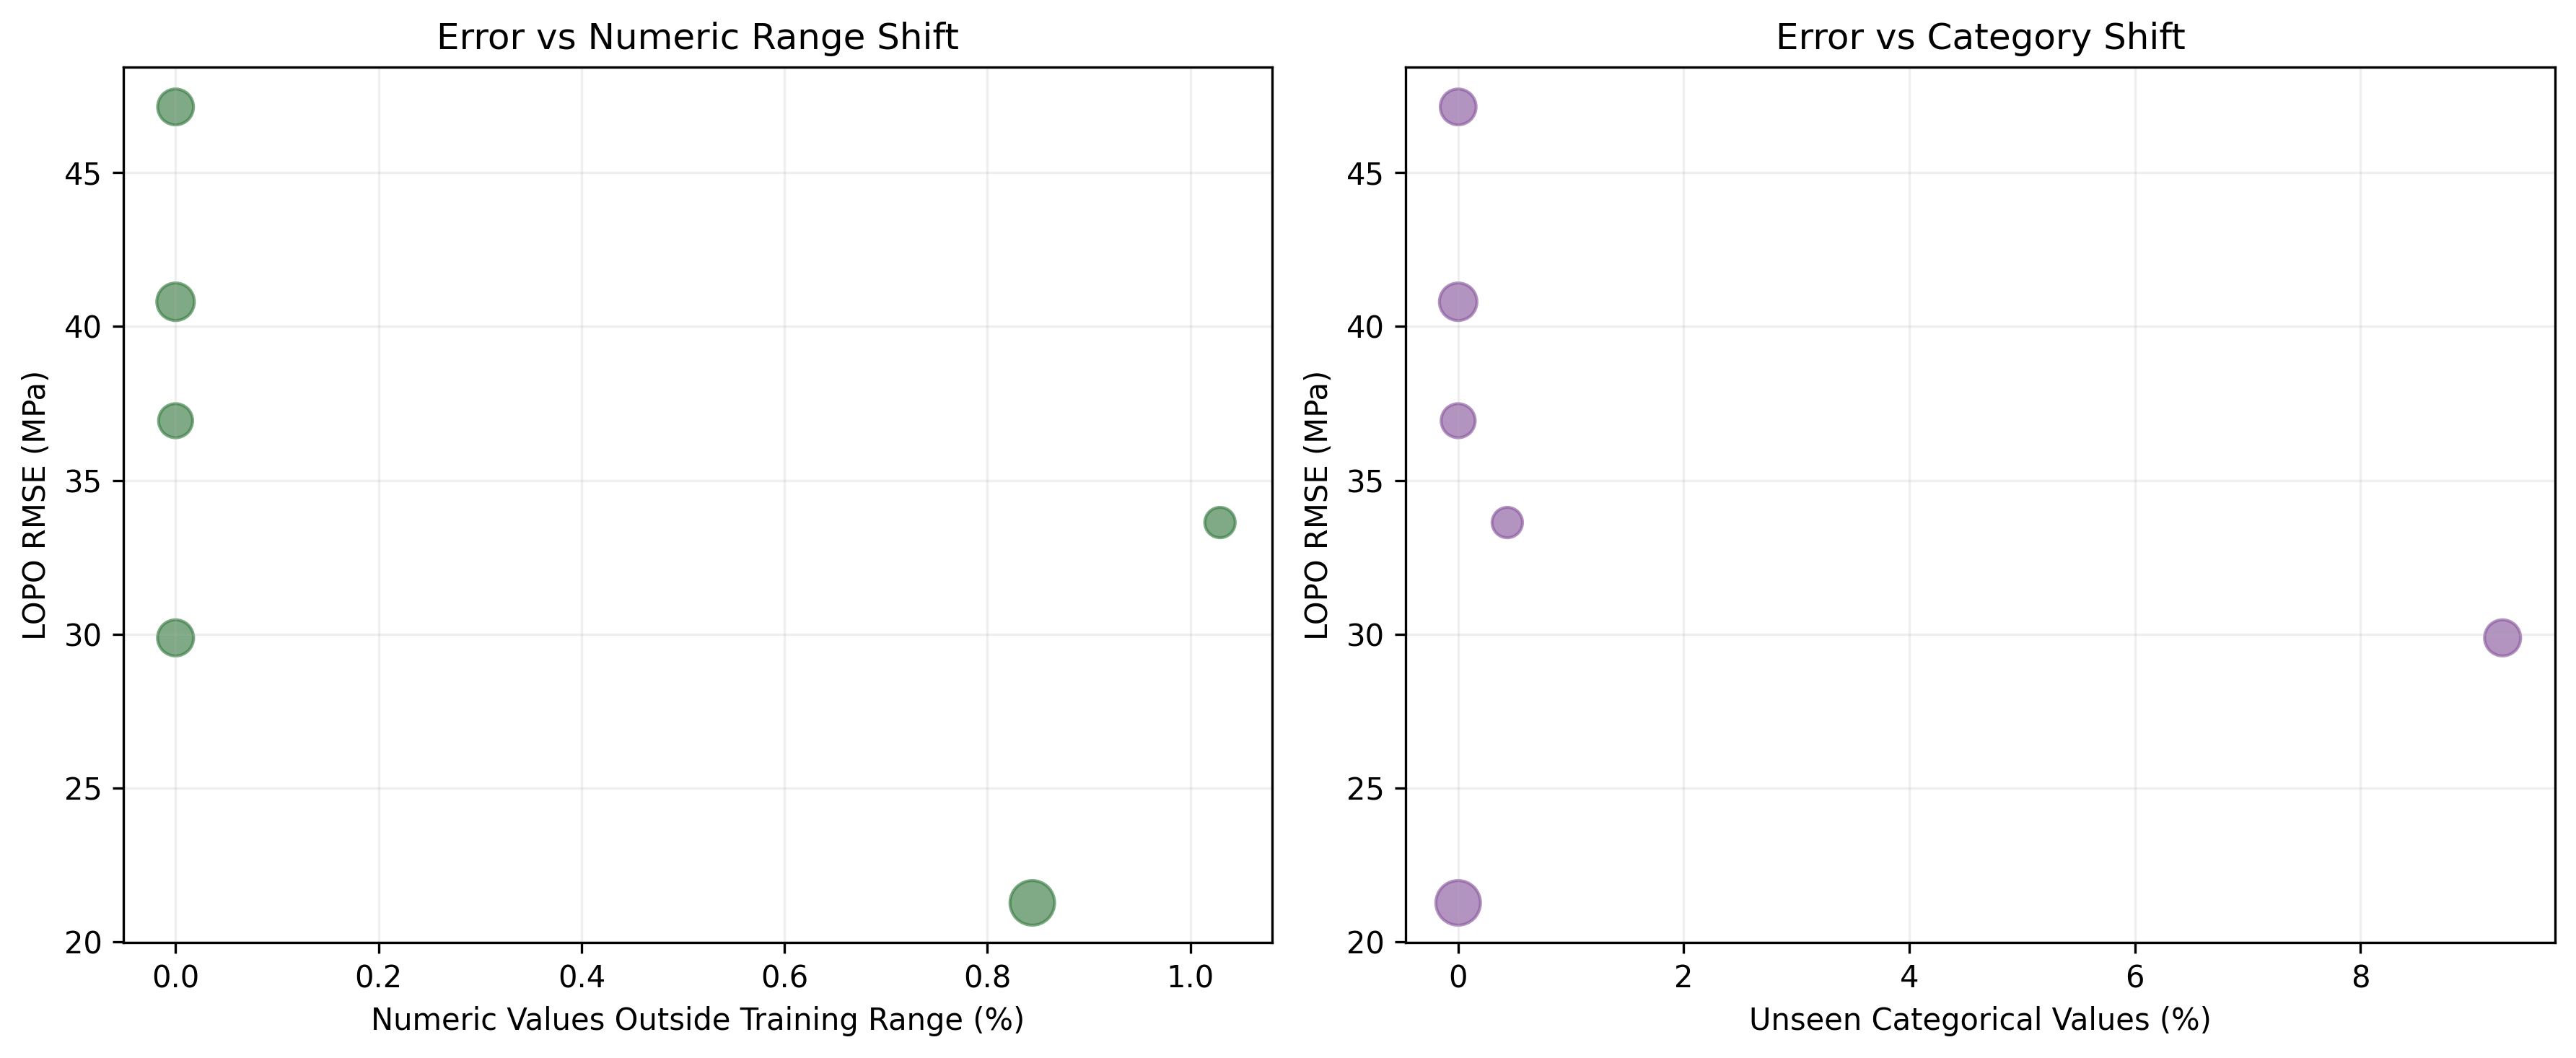

In [24]:
show_figure('week08_lopo_shift_diagnostics.png', width=1200)

In [25]:
shift_correlations = lopo_metrics[[
    'RMSE', 'MAE', 'Bias', 'target_mean',
    'numeric_out_of_training_range_rate', 'unseen_category_rate'
]].corr()
shift_correlations.loc[['RMSE', 'MAE'], [
    'target_mean', 'numeric_out_of_training_range_rate', 'unseen_category_rate'
]].round(3)

,target_mean,numeric_out_of_training_range_rate,unseen_category_rate
RMSE,-0.348,-0.591,-0.283
MAE,-0.334,-0.646,-0.236


### Shift-diagnostic interpretation

The relationship between RMSE and the simple shift diagnostics is not convincing. The two highest-RMSE publications have no numeric values outside the training range and no unseen categories.

This means the model can fail even when individual feature values look familiar. The missing information may be in relationships that are not represented, measurement procedures, material chemistry, laboratory effects, or semantic differences hidden behind harmonized labels.

Only six publications are eligible, so correlation coefficients in the diagnostic table are highly unstable and should not be treated as general evidence. Target statistics are used only for post-hoc explanation, never as predictors.

## 16. What My Conclusion About Each Model says for Week 8 

### OLS
OLS provides a useful reference and performs reasonably under publication validation, but unregularized coefficients are less protected against unstable publication-specific relationships.

### Elastic Net
Elastic Net is the most transferable of the four tested models. Its combined L1/L2 penalty reduces reliance on unstable predictors. However, its final unseen-publication accuracy is still weak, so regularization alone cannot solve the dataset shift.

### Bayesian Ridge
Bayesian Ridge is close to Elastic Net under publication-group CV and validation. This supports the conclusion that conservative regularized linear effects transfer better than the expanded nonlinear representation.

### Polynomial Ridge
Polynomial Ridge is strongest in Week 7 row-mixed evaluation but weakest under publication validation. It fits training data extremely well, yet many learned interactions do not transfer. Its Week 8 behavior is a clear example of why strong row-mixed performance does not guarantee cross-publication generalization.

## 17. Limitations

1. **Fixed upstream feature policy:** The chosen 50% policy was using full-dataset missingness. It is treated as a fixed team representation, but a fully publication-safe feature-policy experiment would learn feature inclusion from training publications only.
2. **Incomplete publication-level variables:** laboratory identity, detailed testing procedure, specimen geometry, material chemistry, and full curing history are not completely represented.
3. **Publication split sensitivity:** one shared split is required for fair model comparison, but results can vary with which publications enter test. LOPO reduces this concern but does not remove it entirely.
4. **Restricted LOPO coverage:** publication-level metrics are unreliable for small groups, so LOPO uses a minimum of 50 rows. This improves per-publication metric stability but reduces coverage to the six largest eligible publications.
5. **R2 interpretation:** publication-level R2 can be highly negative when a publication has a narrow target range. MAE, RMSE, and Bias should be interpreted alongside it.

## 18. Recommended Improvements

### Highest priority: improve the data representation

1. Preserve specimen geometry and testing standards as predictors when consistently available.
2. Add detailed curing history, not only broad curing method and temperature.
3. Preserve cement, SCM, filler, and fiber chemistry or source information.
4. Standardize units and category semantics more deeply across publications.
5. Audit publication-specific missingness and reporting conventions.

### Modeling improvements

1. Evaluate Week 7 engineering ratio features under publication-held-out validation; their row-mixed benefit may not transfer.
2. Try robust linear regression to reduce sensitivity to unusual publications and rows.
3. Consider hierarchical or mixed-effects models that estimate publication variation explicitly while learning shared material effects.
4. Use repeated publication-held-out splits for uncertainty intervals around the generalization gap.
5. Continue reporting both row-level and publication-level metrics.

## 19. My Final Conclusions from this Week's Experiments are:

1. **Evaluation design changes the scientific conclusion.** Row-mixed evaluation suggests useful performance, while publication-held-out evaluation reveals weak transfer to new publications.
2. **Polynomial Ridge does not generalize best.** Its strong Week 7 result appears partly driven by publication-specific nonlinear patterns.
3. **Elastic Net is the most transferable tested model**, but its unseen-publication test RMSE of 34.465 MPa and negative R2 are not satisfactory.
4. **Publication failures are often systematic**, with entire publications consistently overpredicted or underpredicted.
5. **The 50-row LOPO analysis confirms weak transfer on the six largest eligible publications.** It gives micro RMSE **35.009 MPa** and R2 **-0.158**, but covers only **21.8%** of modeling rows.
6. **Simple out-of-range and unseen-category diagnostics do not fully explain failure.** Important publication-level information is likely missing.
7. **Future work should prioritize richer, more consistent metadata and publication-aware evaluation**, rather than relying only on row-mixed performance improvements.